# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to analyze the cleaned Google Play Store dataset, identify key business insights, understand user and app trends, and generate findings that will support SQL analysis, Power BI dashboard development, and business recommendations.

#### Dataset Overview

This section provides a high-level summary of the cleaned dataset, including the total number of apps, categories, and key app characteristics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/cleaned/google_playstore_cleaned.csv")

In [4]:
df.shape

(2312944, 23)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 23 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           str    
 1   App Id             str    
 2   Category           str    
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           float64
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           str    
 11  Size               float64
 12  Minimum Android    str    
 13  Developer Id       str    
 14  Developer Website  str    
 15  Developer Email    str    
 16  Released           str    
 17  Last Updated       str    
 18  Content Rating     str    
 19  Privacy Policy     str    
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
dtypes: bool(4), float64(6), int64(1), str(12)
memory usage: 344.1 MB


In [6]:
total_apps = len(df)
print(f"Total Apps: {total_apps:,}")

Total Apps: 2,312,944


In [7]:
total_categories = df["Category"].nunique()
print(f"Total Categories: {total_categories}")

Total Categories: 48


In [8]:
df["Free"].value_counts()

Free
True     2267876
False      45068
Name: count, dtype: int64

In [9]:
free_percentage = (df["Free"].mean()) * 100

print(f"Free Apps: {free_percentage:.2f}%")
print(f"Paid Apps: {100-free_percentage:.2f}%")

Free Apps: 98.05%
Paid Apps: 1.95%


In [10]:
df["Editors Choice"].value_counts()

Editors Choice
False    2312091
True         853
Name: count, dtype: int64

In [11]:
summary = pd.DataFrame({
    "Metric": [
        "Total Apps",
        "Total Categories",
        "Free Apps (%)",
        "Paid Apps (%)",
        "Editors' Choice Apps"
    ],
    "Value": [
        len(df),
        df["Category"].nunique(),
        round(df["Free"].mean()*100,2),
        round((1-df["Free"].mean())*100,2),
        df["Editors Choice"].sum()
    ]
})

summary

,Metric,Value
0,Total Apps,2312944.00
1,Total Categories,48.00
2,Free Apps (%),98.05
3,Paid Apps (%),1.95
4,Editors' Choice Apps,853.00


### Key Insights

- The dataset contains **2312944** applications across **48** categories.
- Free apps constitute the majority of the Google Play Store.
- Only a small fraction of applications receive the **Editors' Choice** badge, indicating its exclusivity.

### Category Analysis

This section analyzes the distribution of applications across different categories to identify the most and least represented segments in the Google Play Store.

In [12]:
category_count = (
    df["Category"]
    .value_counts()
    .reset_index()
)

category_count.columns = ["Category", "Number of Apps"]

category_count.head(10)

,Category,Number of Apps
0,Education,241090
1,Music & Audio,154906
2,Tools,143988
3,Business,143771
4,Entertainment,138276
5,Lifestyle,118331
6,Books & Reference,116728
7,Personalization,89210
8,Health & Fitness,83510
9,Productivity,79698


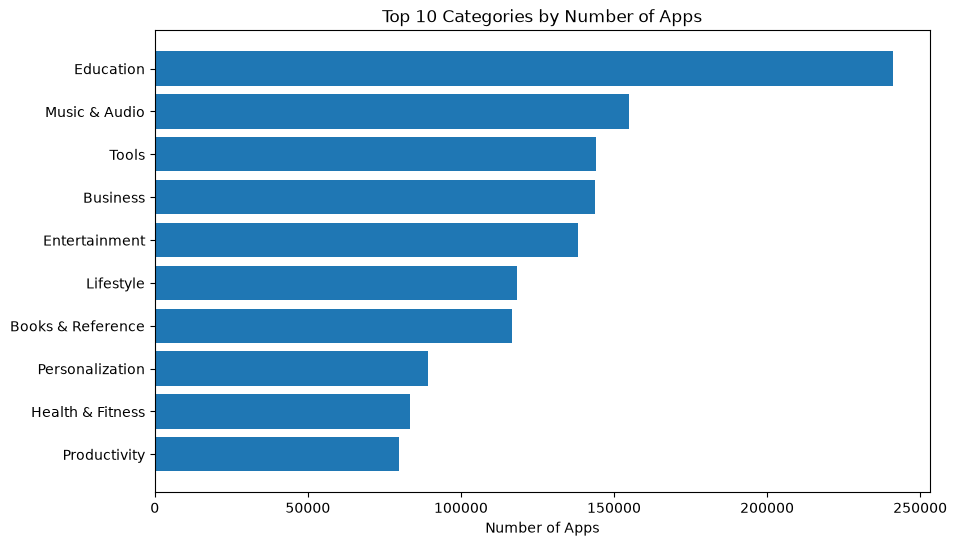

In [13]:
top10 = category_count.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Category"], top10["Number of Apps"])

plt.title("Top 10 Categories by Number of Apps")

plt.xlabel("Number of Apps")

plt.gca().invert_yaxis()

plt.show()

In [14]:
category_count.tail(10)

,Category,Number of Apps
38,Word,8630
39,Strategy,8526
40,Card,8179
41,Weather,7246
42,Dating,6524
43,Libraries & Demo,5198
44,Casino,5076
45,Music,4202
46,Parenting,3810
47,Comics,2862


### Key Findings

- **Most Represented Categories:** Education has the highest number of applications, followed by Music & Audio, Tools, and Business, indicating these are highly competitive segments within the Google Play Store.
- **Least Represented Categories:** Comics, Parenting, Music, and Casino contain the fewest applications, suggesting comparatively smaller or niche market segments.

## Average Ratings by Category

This analysis identifies categories with the highest average user ratings while considering only categories with a sufficient number of rated applications to ensure meaningful comparisons.

In [15]:
category_rating = (
    df.groupby("Category")
      .agg(
          Average_Rating=("Rating", "mean"),
          Rated_Apps=("Rating", "count")
      )
      .reset_index()
)

In [16]:
category_rating = category_rating[
    category_rating["Rated_Apps"] >= 500
]

In [17]:
category_rating = category_rating.sort_values(
    by="Average_Rating",
    ascending=False
)

category_rating.head(10)

,Category,Average_Rating,Rated_Apps
36,Role Playing,3.384498,9657
10,Casino,3.279682,5035
38,Simulation,3.210887,22724
46,Weather,3.120295,7130
9,Card,3.085160,8046
35,Racing,2.960385,10178
45,Video Players & Editors,2.903842,13925
47,Word,2.902076,8525
41,Strategy,2.878900,8237
12,Comics,2.864906,2821


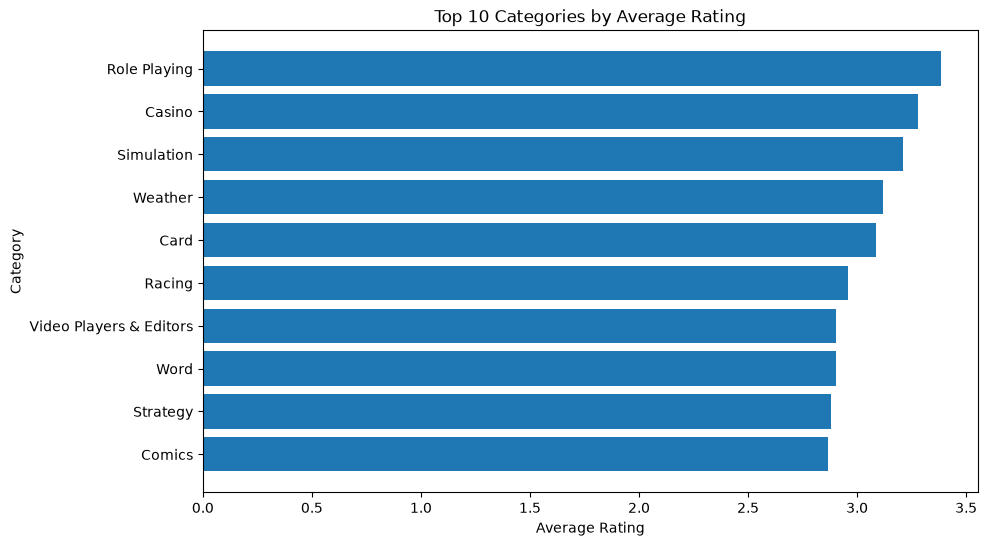

In [18]:
top10 = category_rating.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Category"], top10["Average_Rating"])

plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.title("Top 10 Categories by Average Rating")

plt.gca().invert_yaxis()

plt.show()

In [19]:
df["Rating"].describe()

count    2.290061e+06
mean     2.203152e+00
std      2.106223e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.900000e+00
75%      4.300000e+00
max      5.000000e+00
Name: Rating, dtype: float64

In [20]:
category_rating.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

,Category,Average_Rating,Rated_Apps
36,Role Playing,3.384498,9657
10,Casino,3.279682,5035
38,Simulation,3.210887,22724
46,Weather,3.120295,7130
9,Card,3.085160,8046
35,Racing,2.960385,10178
45,Video Players & Editors,2.903842,13925
47,Word,2.902076,8525
41,Strategy,2.878900,8237
12,Comics,2.864906,2821


In [21]:
(df["Rating"] == 0).sum()

np.int64(1059762)

### Observation

The initial analysis showed an unusually low average rating (2.20), which is not typical for Google Play Store data. Further investigation revealed that over **1 million** apps had a rating of **0**. Since Play Store ratings range from **1.0 to 5.0**, these values are treated as placeholders for apps with no user ratings. Therefore, they will be converted to missing values (`NaN`) before performing rating-based analyses.

In [22]:
df["Rating"] = df["Rating"].replace(0, np.nan)

In [23]:
df["Rating"].describe()

count    1.230299e+06
mean     4.100915e+00
std      6.891015e-01
min      1.000000e+00
25%      3.800000e+00
50%      4.200000e+00
75%      4.600000e+00
max      5.000000e+00
Name: Rating, dtype: float64

In [24]:
(df["Rating"] == 0).sum()

np.int64(0)

### Action Performed

Apps with a rating of **0** were converted to missing values (`NaN`) because Google Play Store ratings are valid only between **1.0 and 5.0**. This ensures that unrated apps do not distort rating-based analyses.

In [26]:
category_rating = (
    df.groupby("Category")
      .agg(
          Average_Rating=("Rating", "mean"),
          Rated_Apps=("Rating", "count")
      )
      .reset_index()
)

In [27]:
category_rating = category_rating.sort_values(
    by="Average_Rating",
    ascending=False
)

In [28]:
category_rating.head(10)

,Category,Average_Rating,Rated_Apps
28,Music & Audio,4.293244,80183
7,Books & Reference,4.287158,67039
18,Events,4.285049,3759
2,Arcade,4.260515,30315
31,Personalization,4.247673,57811
34,Puzzle,4.231100,31939
47,Word,4.222598,5859
15,Education,4.200601,128258
39,Social,4.185545,25243
37,Shopping,4.184839,32814


In [30]:
category_rating.tail(10)

,Category,Average_Rating,Rated_Apps
12,Comics,3.928974,2057
42,Tools,3.916256,85050
32,Photography,3.903016,22845
25,Maps & Navigation,3.898623,15037
27,Music,3.894315,2832
4,Auto & Vehicles,3.890104,9458
14,Dating,3.829135,4129
45,Video Players & Editors,3.817238,10593
38,Simulation,3.814124,19130
22,House & Home,3.798683,5542


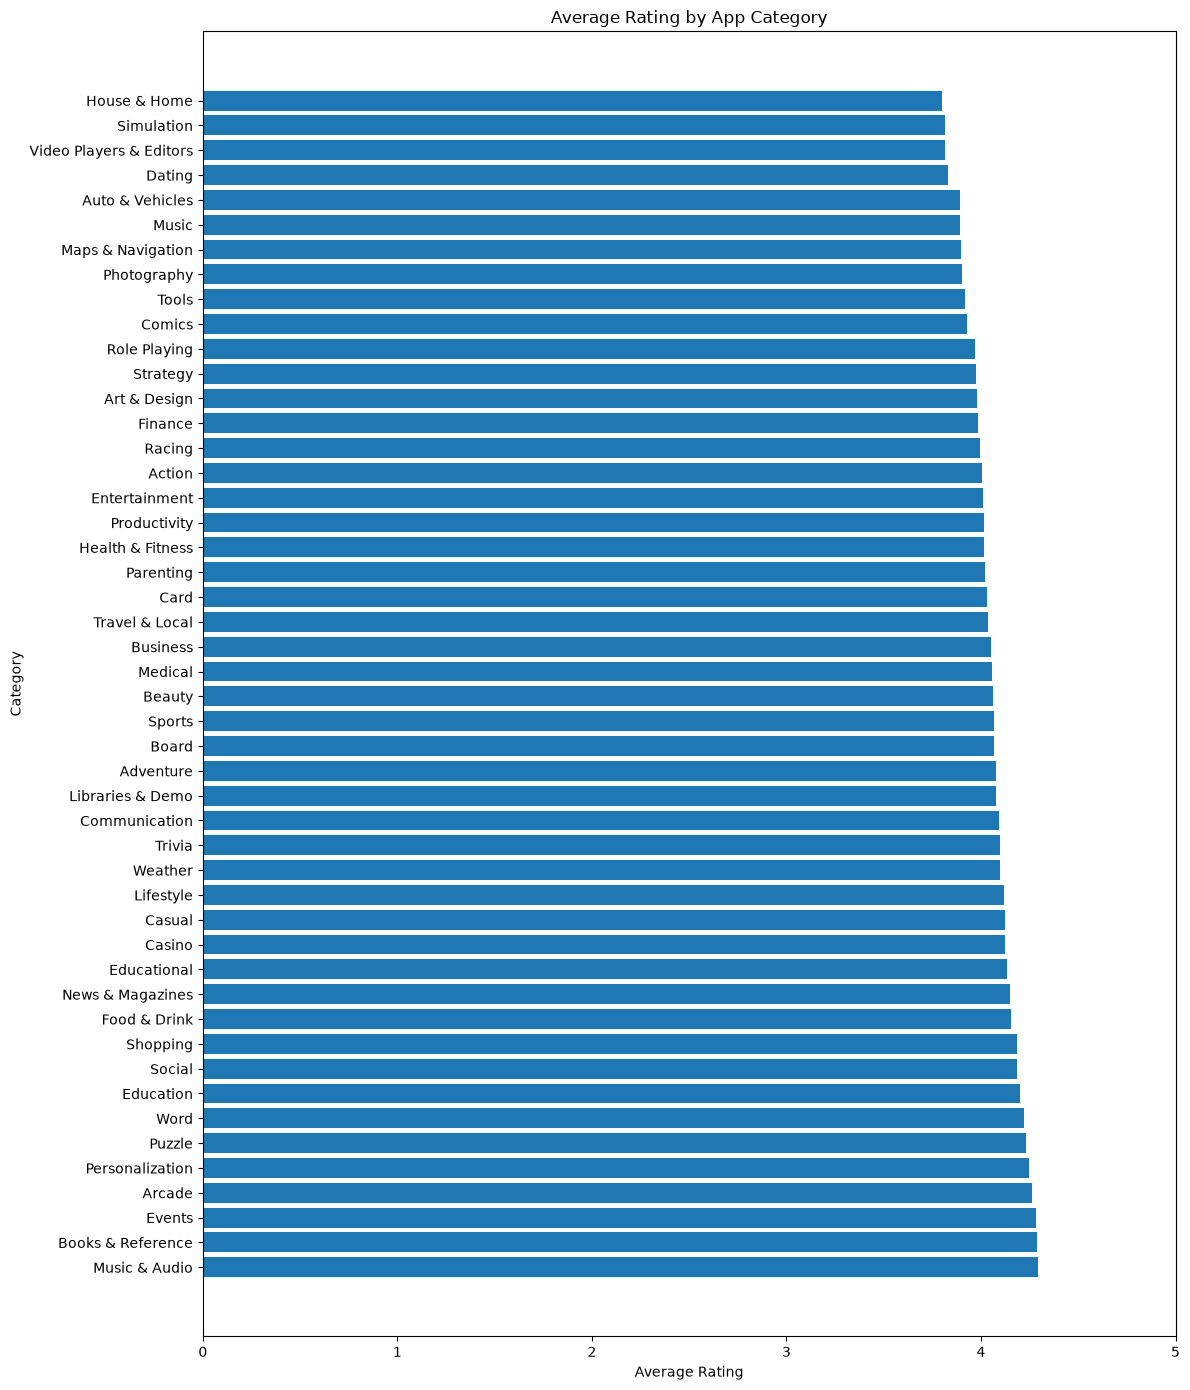

In [31]:
plt.figure(figsize=(12, 14))

plt.barh(
    category_rating["Category"],
    category_rating["Average_Rating"]
)

plt.title("Average Rating by App Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

### Key Findings

- After treating unrated apps (rating = 0) as missing values, the average ratings became more representative of actual user feedback.
- Understanding category-wise ratings helps identify app segments that perform well in terms of user satisfaction and overall app quality.

## Category-wise Installs

This analysis examines the total and average number of installs across app categories to identify the most popular segments in the Google Play Store.

In [32]:
category_installs = (
    df.groupby("Category")
      .agg(
          Total_Installs=("Maximum Installs", "sum"),
          Average_Installs=("Maximum Installs", "mean"),
          Total_Apps=("App Id", "count")
      )
      .reset_index()
)

In [33]:
category_installs = category_installs.sort_values(
    by="Total_Installs",
    ascending=False
)

category_installs.head(10)

,Category,Total_Installs,Average_Installs,Total_Apps
42,Tools,119849500546,8.323576e+05,143988
13,Communication,72306404399,1.501161e+06,48167
33,Productivity,45368330480,5.692531e+05,79698
17,Entertainment,32544902249,2.353619e+05,138276
39,Social,32216881194,7.201878e+05,44734
32,Photography,31590959146,8.885846e+05,35552
45,Video Players & Editors,31439400808,2.243268e+06,14015
0,Action,30742136749,1.115665e+06,27555
11,Casual,30525269577,6.007374e+05,50813
2,Arcade,25681896317,4.774297e+05,53792


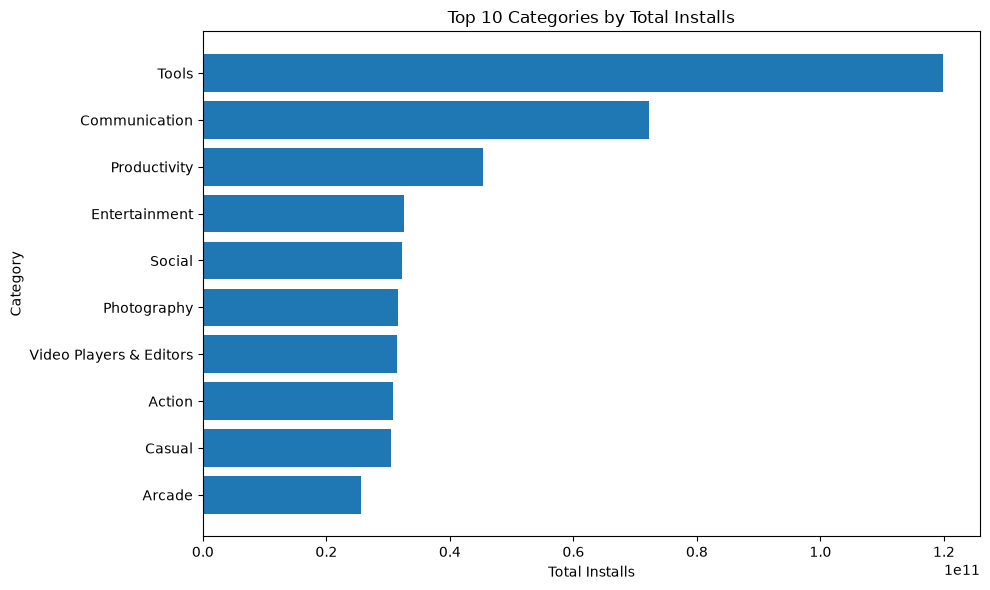

In [34]:
top10 = category_installs.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Category"], top10["Total_Installs"])

plt.title("Top 10 Categories by Total Installs")

plt.xlabel("Total Installs")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Key Findings

- The **Tools** category has the highest total installs, indicating the largest overall user reach despite not having the highest number of applications.
- Categories such as **Communication**, **Productivity**, and **Entertainment** also record significantly high install counts, highlighting strong user demand.
- A higher number of published apps does not necessarily translate to higher installs. For example, **Education** has the largest number of apps but is not among the top categories by total installs.

## Average Installs per App by Category

This analysis calculates the average number of installs per app for each category. Unlike total installs, this metric highlights categories where individual apps perform well on average, helping identify segments with strong growth potential and lower competition.

In [35]:
category_installs = category_installs.sort_values(
    by="Average_Installs",
    ascending=False
)

category_installs.head(10)

,Category,Total_Installs,Average_Installs,Total_Apps
45,Video Players & Editors,31439400808,2.243268e+06,14015
35,Racing,17093737289,1.649656e+06,10362
13,Communication,72306404399,1.501161e+06,48167
0,Action,30742136749,1.115665e+06,27555
41,Strategy,7691357340,9.021062e+05,8526
32,Photography,31590959146,8.885846e+05,35552
36,Role Playing,8646146865,8.616850e+05,10034
38,Simulation,19957063168,8.571885e+05,23282
42,Tools,119849500546,8.323576e+05,143988
27,Music,3261642266,7.762119e+05,4202


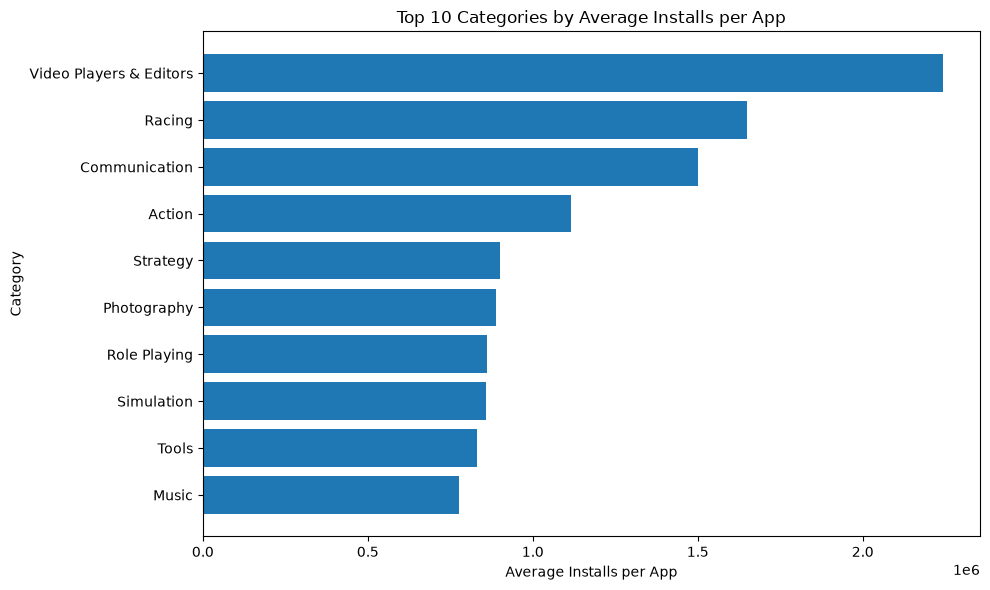

In [36]:
top10 = category_installs.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Category"],
    top10["Average_Installs"]
)

plt.title("Top 10 Categories by Average Installs per App")

plt.xlabel("Average Installs per App")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Key Findings

- **Video Players & Editors** has the highest average installs per app, indicating that apps in this category achieve strong user reach on an individual basis.
- Although the **Tools** category records the highest total installs, its average installs per app are lower due to the large number of competing apps.
- Average installs per app provide a better measure of an app category's success potential, helping identify categories where individual apps are more likely to achieve higher user adoption.